In [8]:
pip install tensorflow streamlit matplot numpy pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


In [11]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [12]:
img_width = 180
img_height =180 

In [13]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3115 files belonging to 36 classes.


In [14]:
data_cat = data_train.class_names

In [15]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [16]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [17]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


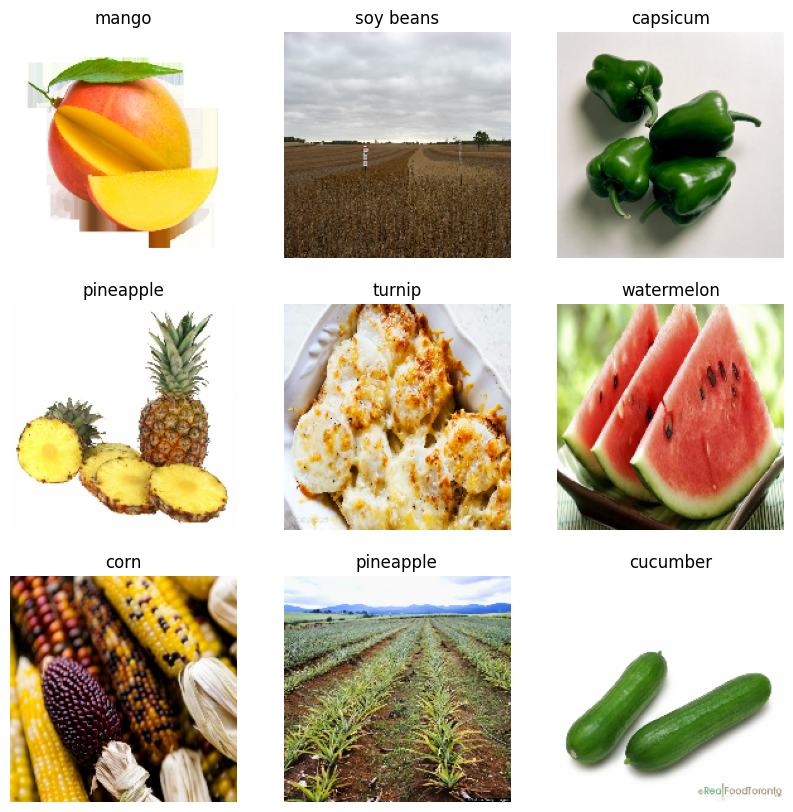

In [18]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [19]:
from tensorflow.keras.models import Sequential

In [20]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [21]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
                  
])

In [22]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [23]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 74s 683ms/step - accuracy: 0.0697 - loss: 3.5327 - val_accuracy: 0.2792 - val_loss: 2.8882
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 617ms/step - accuracy: 0.2125 - loss: 2.7879 - val_accuracy: 0.4786 - val_loss: 1.9961
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 605ms/step - accuracy: 0.4250 - loss: 2.0466 - val_accuracy: 0.7350 - val_loss: 1.1346
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 416s 623ms/step - accuracy: 0.6395 - loss: 1.2900 - val_accuracy: 0.8632 - val_loss: 0.6840
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 609ms/step - accuracy: 0.7746 - loss: 0.8014 - val_accuracy: 0.9003 - val_loss: 0.5786
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 632ms/step - accuracy: 0.8761 - loss: 0.4750 - val_accuracy: 0.8917 - val_loss: 0.5468
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 81s 606ms/step - accuracy: 0.8982 - loss: 0.3736 - val_accuracy: 0.9516 - val_loss: 0.4289
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 619ms/step - accuracy: 0.9262 - loss: 0.2864 - val_acc

Text(0.5, 1.0, 'Loss')

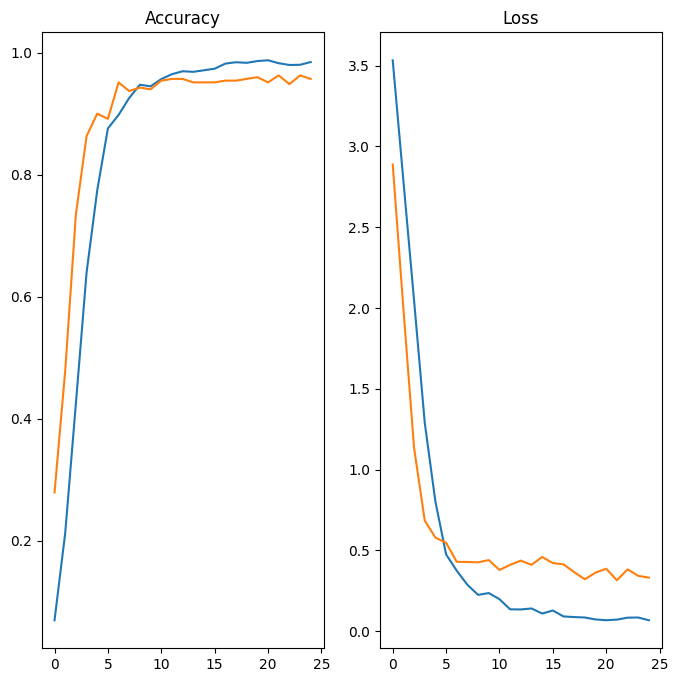

In [24]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [25]:
image = 'Image_39.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [26]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


In [27]:
score = tf.nn.softmax(predict)

In [28]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is corn with accuracy of 99.11


In [29]:
model.save('Image_classify.keras')